In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

In [17]:

# 2つのCSVファイルを読み込み
sake_data = pd.read_csv('/Users/yugo_suzuki/mydevelopment/development/test/data-dami-sake/buy_check_dummy_data.csv', encoding='utf-8')
whisky_data = pd.read_csv('/Users/yugo_suzuki/mydevelopment/development/test/data-dami-whisky/buy_check_dummy_data_whisky.csv', encoding='utf-8')

# データを結合
data = pd.concat([sake_data, whisky_data], ignore_index=True)

In [18]:
# 購入日時を datetime 型に変換し、日付部分だけを取り出す
data['購入日'] = pd.to_datetime(data['購入日時']).dt.date

# 商品名と日付ごとの購入件数をカウント（行数＝件数）
daily_product_counts = data.groupby(['購入日', '商品名']).size().reset_index(name='購入件数')

# 結果を表示
print(daily_product_counts)

             購入日                          商品名  購入件数
0     2025-04-01                        LINK8     1
1     2025-04-01                  あかし シングルモルト    13
2     2025-04-01                あかし7年 シングルモルト     1
3     2025-04-01               くら ブレンデットウイスキー     6
4     2025-04-01  くら ラムスカスクフィニッシュ ブレンデットウイスキー     5
...          ...                          ...   ...
1392  2025-04-30                         神巖富士     6
1393  2025-04-30                          菊正宗     1
1394  2025-04-30                           酔心     5
1395  2025-04-30                         雪の茅宿     2
1396  2025-04-30                  鳳凰酔心　山田綿50%     5

[1397 rows x 3 columns]


/var/folders/nq/pf4848v92qq76wvlqb4x38j40000gn/T/ipykernel_73041/3201362267.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', n_clusters)


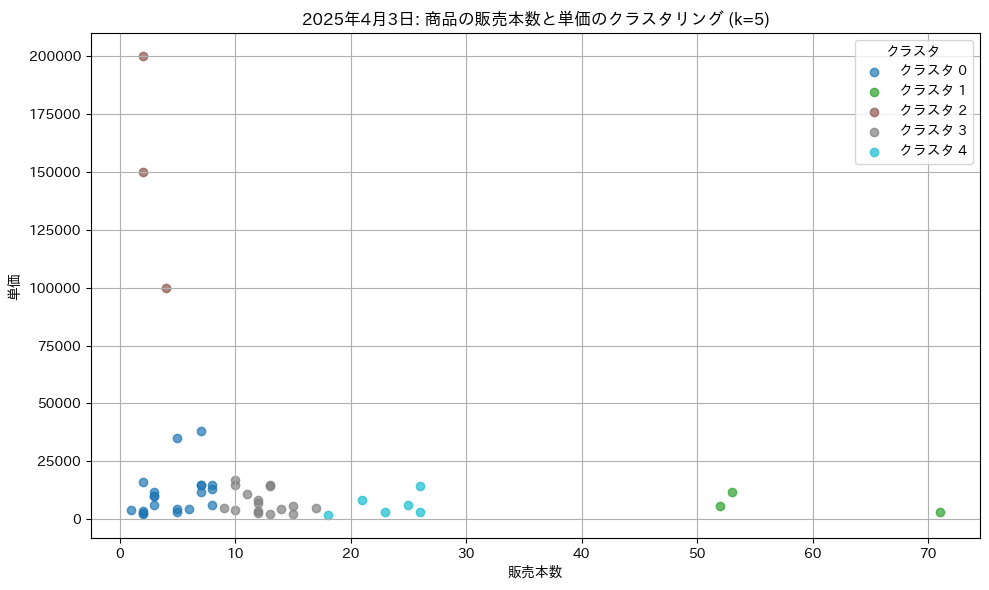

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler  # スケーリングを追加

# クラスタ数（ここを変えるとグループ数を変更可能）
n_clusters = 5

# 日付の変換と絞り込み（例：2025年4月3日）
data['購入日'] = pd.to_datetime(data['購入日'])
data_april_3rd = data[data['購入日'] == '2025-04-03']

# 商品ごとに販売本数（数量合計）と単価を集計
grouped = data_april_3rd.groupby('商品名').agg(
    販売本数=('数量', 'sum'),
    単価=('単価', 'first')
).reset_index()

# 特徴量のスケーリング（販売本数と単価のスケール差を補正）
scaler = StandardScaler()
scaled_features = scaler.fit_transform(grouped[['販売本数', '単価']])

# KMeansクラスタリングの実行（2次元特徴量で）
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
grouped['クラスタ'] = kmeans.fit_predict(scaled_features)

# クラスタごとに色を自動割り当て（色数が足りるように調整）
import matplotlib.cm as cm
import numpy as np
colors = cm.get_cmap('tab10', n_clusters)

# 散布図の表示
plt.figure(figsize=(10, 6))

for cluster in range(n_clusters):
    cluster_data = grouped[grouped['クラスタ'] == cluster]
    plt.scatter(cluster_data['販売本数'], cluster_data['単価'],
                label=f'クラスタ {cluster}',
                color=colors(cluster),
                marker='o', alpha=0.7)

# ラベル・タイトル・凡例など
plt.xlabel('販売本数')
plt.ylabel('単価')
plt.title(f'2025年4月3日: 商品の販売本数と単価のクラスタリング (k={n_clusters})')
plt.grid(True)
plt.legend(title='クラスタ')
plt.tight_layout()
plt.show()



--- 各クラスタに属する商品名一覧 (k=4) ---

クラスタ 0 (25 件):
  - LINK8
  - あかし7年 シングルモルト
  - くら ブレンデットウイスキー
  - 九平次彼の岸
  - 倉吉 シングルモルト
  - 倉吉12年 ブレンデットウイスキー
  - 倉吉18年 ブレンデットウイスキー
  - 八海山　浩和蔵仕込
  - 大関十段仕込
  - 宮の雪
  - 富士山 ブレンデットウイスキー
  - 小正嘉之介MBR シングルモルト
  - 小正嘉之介MDS シングルモルト
  - 小正嘉之介W-Ds MBR シングルモルト
  - 戸河内四季 ブレンデットウイスキー
  - 月桂冠大吟醸山田綿
  - 月桂冠純米大吟醸
  - 月桂冠龍馬伝
  - 桜尾 SHERRY-CASK シングルモルト
  - 桜尾四季 シングルモルト
  - 獺祭未来へ農家と共に
  - 獺祭磨きその先に
  - 菊正宗
  - 雪の茅宿
  - 鳳凰酔心　山田綿30%

クラスタ 1 (3 件):
  - 獺祭早田
  - 獺祭２割3分
  - 獺祭３割9分

クラスタ 2 (3 件):
  - 倉吉25年 ブレンデットウイスキー
  - 倉吉29年 ブレンデットウイスキー
  - 倉吉31年 ブレンデットウイスキー

クラスタ 3 (17 件):
  - あかし シングルモルト
  - くら ラムスカスクフィニッシュ ブレンデットウイスキー
  - サントリーローヤル ブレンデットウイスキー
  - 九平次human
  - 九平次別誂
  - 余市　シングルモルト
  - 八海山
  - 千代菊　大吟醸
  - 千代菊日本人形
  - 宮城峡　シングルモルト
  - 岡山　シングルモルト
  - 戸河内 ブレンデットウイスキー
  - 桜尾 シングルモルト
  - 碧AO ブレンデットウイスキー
  - 神巖富士
  - 酔心
  - 鳳凰酔心　山田綿50%


/var/folders/nq/pf4848v92qq76wvlqb4x38j40000gn/T/ipykernel_73041/4109359047.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', n_clusters)


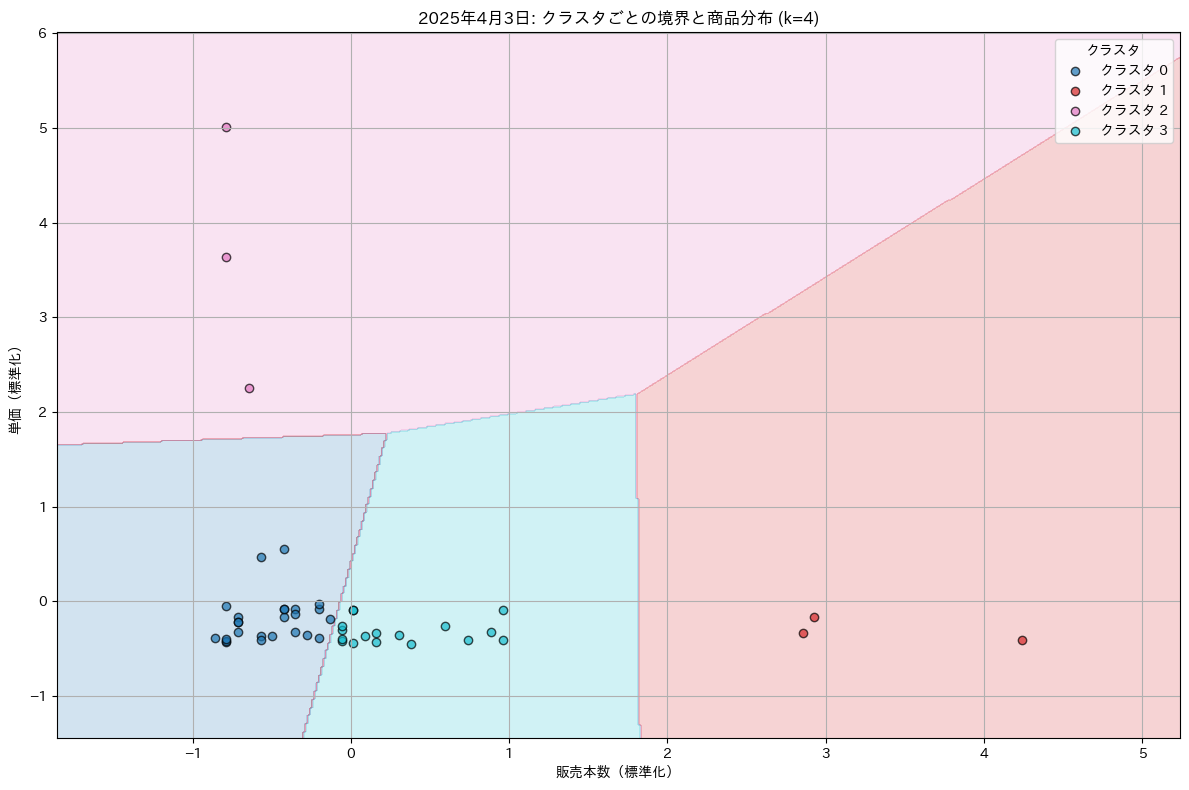

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.cm as cm

# クラスタ数（変更可能）
n_clusters = 4

# 日付の変換と絞り込み
data['購入日'] = pd.to_datetime(data['購入日'])
data_april_3rd = data[data['購入日'] == '2025-04-03']

# 商品ごとの販売本数と単価を集計
grouped = data_april_3rd.groupby('商品名').agg(
    販売本数=('数量', 'sum'),
    単価=('単価', 'first')
).reset_index()

# 特徴量のスケーリング
scaler = StandardScaler()
scaled_features = scaler.fit_transform(grouped[['販売本数', '単価']])

# KMeansクラスタリング
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
grouped['クラスタ'] = kmeans.fit_predict(scaled_features)

# クラスタごとの商品名を出力
print(f"\n--- 各クラスタに属する商品名一覧 (k={n_clusters}) ---")
for cluster in range(n_clusters):
    products = grouped[grouped['クラスタ'] == cluster]['商品名'].tolist()
    print(f"\nクラスタ {cluster} ({len(products)} 件):")
    for name in products:
        print(f"  - {name}")

# 以下はプロット部分（スケーリング後の座標で境界表示）
x_min, x_max = scaled_features[:, 0].min() - 1, scaled_features[:, 0].max() + 1
y_min, y_max = scaled_features[:, 1].min() - 1, scaled_features[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = kmeans.predict(grid).reshape(xx.shape)

colors = cm.get_cmap('tab10', n_clusters)
plt.figure(figsize=(12, 8))
plt.contourf(xx, yy, Z, alpha=0.2, cmap=colors)

for cluster in range(n_clusters):
    cluster_data = scaled_features[grouped['クラスタ'] == cluster]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1],
                label=f'クラスタ {cluster}',
                color=colors(cluster),
                edgecolor='k', alpha=0.7)

plt.xlabel('販売本数（標準化）')
plt.ylabel('単価（標準化）')
plt.title(f'2025年4月3日: クラスタごとの境界と商品分布 (k={n_clusters})')
plt.grid(True)
plt.legend(title='クラスタ')
plt.tight_layout()
plt.show()
